<a href="https://colab.research.google.com/github/leman-cap13/Machine_Learning/blob/main/Ensemble_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


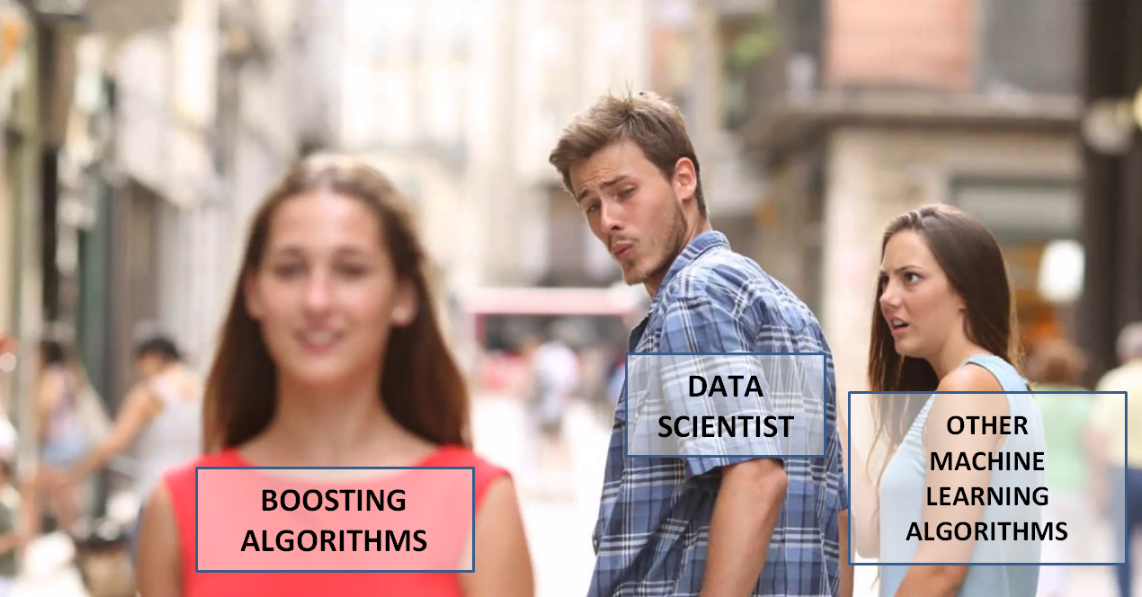



#Ensemble Learning

 Ensemble learning helps improve machine learning results by combining several models. This approach allows the production of better predictive performance compared to a single model.

 Basic idea is to learn a set of classifiers (experts) and to allow them to vote. Bagging and Boosting are two types of Ensemble Learning. These two decrease the variance of a single estimate as they combine several estimates from different models. So the result may be a model with higher stability. Let's understand these two terms in a glimpse.

Bagging: It is a homogeneous weak learners’ model that learns from each other independently in parallel and combines them for determining the model average.

Boosting: It is also a homogeneous weak learners’ model but works differently from Bagging. In this model, learners learn sequentially and adaptively to improve model predictions of a learning algorithm.

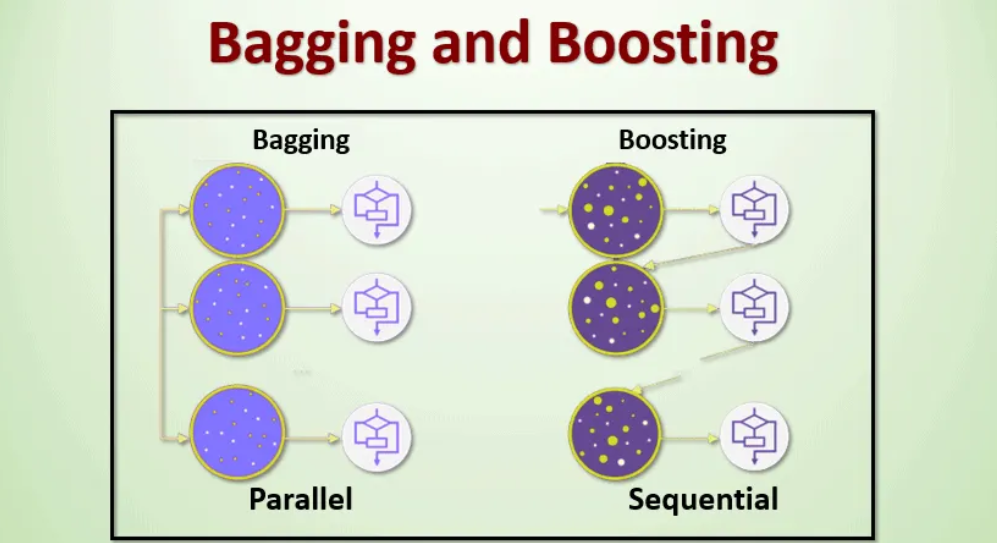

#Bagging model

Bootstrap Aggregating, also known as bagging, is a machine learning ensemble meta-algorithm designed to improve the stability and accuracy of machine learning algorithms used in statistical classification and regression. It decreases the variance and helps to avoid overfitting. It is usually applied to decision tree methods.

In classification tasks, the final prediction is decided by majority voting, the class chosen by most base models.

For regression tasks, predictions are averaged across all base models, known as bagging regression.

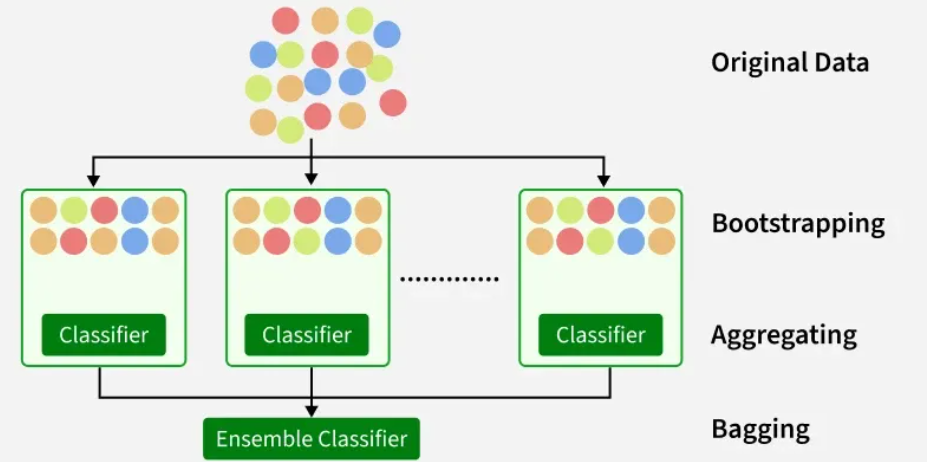

1.Bagging starts with the original training dataset.

2.From this, bootstrap samples (random subsets with replacement) are created. These samples are used to train multiple weak learners, ensuring diversity.

3.Each weak learner independently predicts outcomes, capturing different patterns.

4.Predictions are aggregated using majority voting, where the most voted output becomes the final classification.

5.Out-of-Bag (OOB) evaluation measures model performance using data not included in each bootstrap sample.

Overall, this approach improves accuracy and reduces overfitting.

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lmanqasml","key":"2d851a4eb9cae06770577185722326e0"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d uciml/forest-cover-type-dataset



Dataset URL: https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset
License(s): unknown
  0% 0.00/11.2M [00:00<?, ?B/s]
100% 11.2M/11.2M [00:00<00:00, 706MB/s]


In [ ]:
import zipfile
with zipfile.ZipFile('/content/forest-cover-type-dataset.zip','r') as zip_ref:
  zip_ref.extractall()

In [ ]:
# ! pip install --upgrade scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer



In [ ]:
df=pd.read_csv('/content/covtype.csv')
pd.set_option('display.max_columns', None)
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
581008,2391,152,19,67,12,95,240,237,119,845,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
581009,2386,159,17,60,7,90,236,241,130,854,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
581010,2384,170,15,60,5,90,230,245,143,864,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3


In [ ]:
df.isna().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,0.448865,0.051434,0.436074,0.063627,0.005217,0.012952,0.008301,0.021335,0.002749,0.011316,0.000181,0.000308,0.001974,0.056168,0.021359,0.051584,0.030001,0.001031,0.000005,0.004897,0.005890,0.003268,0.006921,0.015936,0.001442,0.057439,0.099399,0.036622,0.000816,0.004456,0.001869,0.001628,0.198356,0.051927,0.044175,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,0.497379,0.220882,0.495897,0.244087,0.072039,0.113066,0.090731,0.144499,0.052356,0.105775,0.013442,0.017550,0.044387,0.230245,0.144579,0.221186,0.170590,0.032092,0.002272,0.069804,0.076518,0.057077,0.082902,0.125228,0.037950,0.232681,0.299197,0.187833,0.028551,0.066605,0.043193,0.040318,0.398762,0.221879,0.205483,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [ ]:
df.dtypes

,0
Elevation,int64
Aspect,int64
Slope,int64
Horizontal_Distance_To_Hydrology,int64
Vertical_Distance_To_Hydrology,int64
Horizontal_Distance_To_Roadways,int64
Hillshade_9am,int64
Hillshade_Noon,int64
Hillshade_3pm,int64
Horizontal_Distance_To_Fire_Points,int64


In [ ]:
X=df.drop('Cover_Type',axis=1)
y=df['Cover_Type'].copy()

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=42, stratify=y, random_state=42)

In [ ]:
num_features=X_train.select_dtypes(include=[np.number]).columns

In [ ]:
num_features

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40

In [ ]:
num_pipeline=Pipeline(steps=[
    ('scaler',StandardScaler())
])

transformer=ColumnTransformer(transformers=[
    ('num',num_pipeline,num_features)
])

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=50), #weak learner kimi istifade edilen model..Bagging üçün ideal base estimator: High variance modellər → Decision Tree
                                                      #Çünki bagging-in işi variance azaltmaqdır.Variance yüksəkdirsə, bagging güclü olur.
    n_estimators=50, #neçə dənə decision tree
    bootstrap=True, #sampling with replacement
    oob_score=True, #Bootstrap zamanı hər ağac dataset-in 37%-ni görmür.Bu “görmədiyi” nümunələr validation kimi istifadə olunur.
    n_jobs=-1,     # -1 → bütün CPU nüvələrindən istifadə et.
    verbose=1,     #training zamanı log çıxarır:
    random_state=42
)

In [ ]:
model = Pipeline([
    ("preprocessing", transformer),
    ("bagging", bagging_model)
])

In [ ]:
model.fit(X_train,y_train)
#model.oob_score_

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  5.3min finished


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wildern...
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40'],
      dtype='object'))])),
                ('bagging',
                 BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=50),
                                   n_estimators=50, n_jobs=-1, oob_score=True,
                                   random_state=42, verbose=1))])

In [ ]:
model.score(X_train,y_train) , model.score(X_test,y_test)


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   12.6s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.3s finished


(0.9999724598516274, 0.9523809523809523)

In [ ]:
pred=model.predict(X_test)
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))
print(accuracy_score(y_test,pred))
print(f1_score(y_test,pred,average='weighted'))
print(recall_score(y_test,pred,average='weighted'))
print(precision_score(y_test,pred,average='weighted'))

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


              precision    recall  f1-score   support

           1       0.93      0.93      0.93        15
           2       0.95      0.95      0.95        20
           3       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2

    accuracy                           0.95        42
   macro avg       0.98      0.98      0.98        42
weighted avg       0.95      0.95      0.95        42

[[14  1  0  0  0  0]
 [ 1 19  0  0  0  0]
 [ 0  0  3  0  0  0]
 [ 0  0  0  1  0  0]
 [ 0  0  0  0  1  0]
 [ 0  0  0  0  0  2]]
0.9523809523809523
0.9523809523809523
0.9523809523809523
0.9523809523809523


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.3s finished


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:865: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:871: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:865: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:871: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


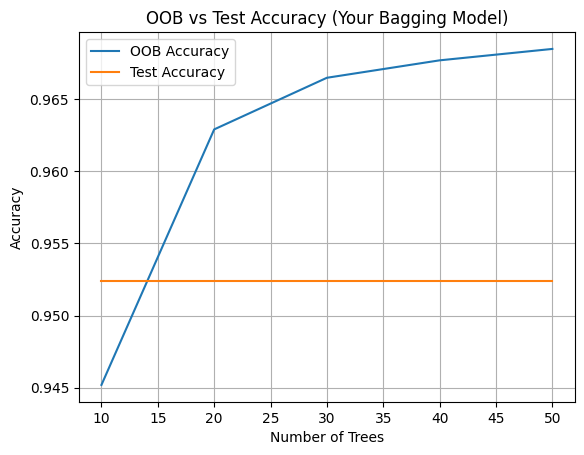

In [ ]:
test_accs = []
oob_accs = []
trees = [10, 20, 30, 40, 50]

for t in trees:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=50),
        n_estimators=t,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    )
    bag.fit(X_train, y_train)

    oob_accs.append(bag.oob_score_)
    test_accs.append(bag.score(X_test, y_test))

plt.plot(trees, oob_accs, label="OOB Accuracy")
plt.plot(trees, test_accs, label="Test Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("OOB vs Test Accuracy (Your Bagging Model)")
plt.legend()
plt.grid()
plt.show()


#Pasting model

In [ ]:
pasting_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=50),
    n_estimators=50,
    max_samples=0.8,      # hər ağac üçün 80% sample (WITHOUT replacement)
    bootstrap=False,      # *** əsas fərq: bootstrap YOXDUR → PASTING
    oob_score=False,      # OOB yalnız bootstrap=True olanda işləyir
    n_jobs=-1,
    verbose=1,
    random_state=42
)


pasting_clf = Pipeline([
    ("preprocessing", transformer),
    ("pasting", pasting_model)
])


pasting_clf.fit(X_train, y_train)


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  6.5min finished


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wildern...
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40'],
      dtype='object'))])),
                ('pasting',
                 BaggingClassifier(bootstrap=False,
                                   estimator=DecisionTreeClassifier(max_depth=50),
                                   max_samples=0.8, n_estimators=50, n_jobs=-1,
                                   random_state=42, verbose=1))])

In [ ]:
y_pred_pasting = pasting_clf.predict(X_test)

print("Pasting test accuracy:",
      accuracy_score(y_test, y_pred_pasting))

print("\nClassification report (Pasting):")
print(classification_report(y_test, y_pred_pasting))

print("\nConfusion matrix (Pasting):")
print(confusion_matrix(y_test, y_pred_pasting))

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Pasting test accuracy: 0.9523809523809523

Classification report (Pasting):
              precision    recall  f1-score   support

           1       0.93      0.93      0.93        15
           2       0.95      0.95      0.95        20
           3       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2

    accuracy                           0.95        42
   macro avg       0.98      0.98      0.98        42
weighted avg       0.95      0.95      0.95        42


Confusion matrix (Pasting):
[[14  1  0  0  0  0]
 [ 1 19  0  0  0  0]
 [ 0  0  3  0  0  0]
 [ 0  0  0  1  0  0]
 [ 0  0  0  0  1  0]
 [ 0  0  0  0  0  2]]


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.3s finished


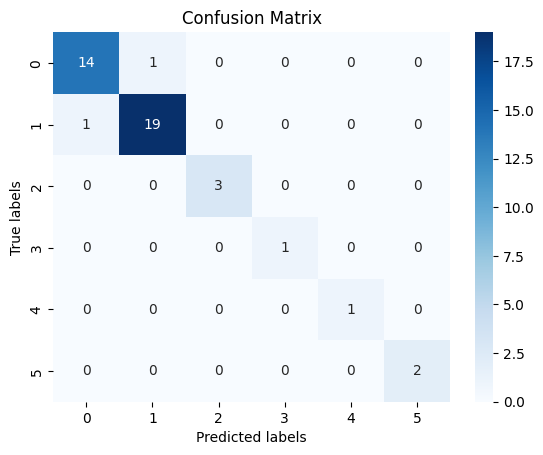

In [ ]:
cm_data = confusion_matrix(y_test, pred)
sns.heatmap(cm_data, annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

#Boosting Models

Boosting is a powerful ensemble learning method in machine learning, specifically designed to improve the accuracy of predictive models by combining multiple weak learners—models that perform only slightly better than random guessing—into a single, strong learner.

The essence of boosting lies in the iterative process where each weak learner is trained to correct the errors of its predecessor, gradually enhancing the overall model's performance. By focusing on the mistakes made by earlier models, boosting turns a collection of weak learners into a more accurate model.

1.Select Initial Weights: Assign initial weights to all data points to indicate their importance in the learning process.

2.Train Sequentially: Train the first weak learner on the data. After evaluating its performance, increase the weights of misclassified instances. This makes the next weak learner focus more on the harder cases.

3.Iterate the Process: Repeat the process of adjusting weights and training subsequent learners. Each new model focuses on the weaknesses of the ensemble thus far.

4.Combine the Results: Aggregate the predictions of all weak learners to form the final output. The aggregation is typically weighted, where more accurate learners have more influence.

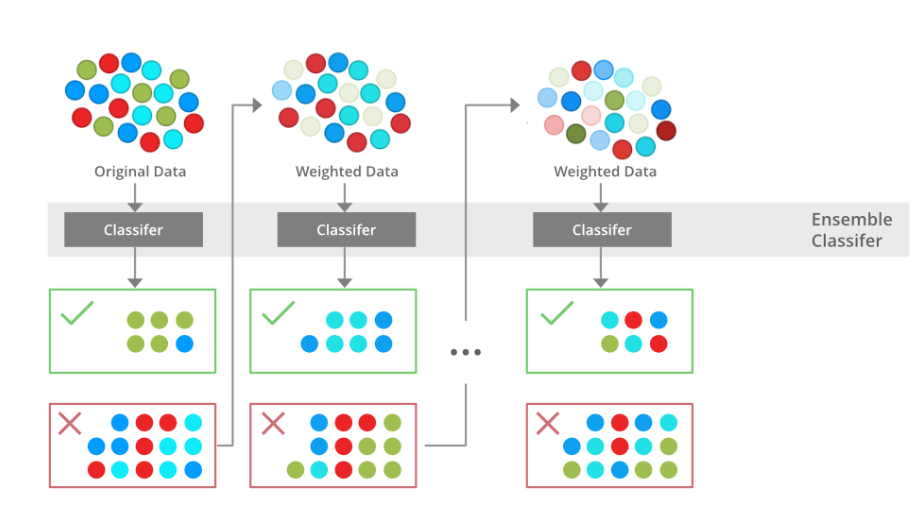

#ADA BOOSTING

AdaBoost is one of the first boosting algorithms. It focuses on reweighting the training examples each time a learner is added, putting more emphasis on the incorrectly classified instances. AdaBoost is particularly effective for binary classification problems.

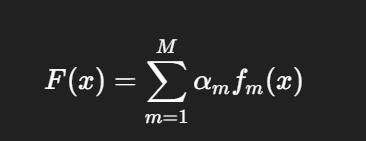

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
base_stump = DecisionTreeClassifier(
    max_depth=1,      # zəif learner (decision stump)
    random_state=42
)

ada = AdaBoostClassifier(
    estimator=base_stump,
    n_estimators=200,   # neçə zəif model
    learning_rate=0.5,  # hər modelin təsir gücü
    random_state=42
)


ada_clf = Pipeline(steps=[
    ("preprocess", transformer),
    ("ada", ada)
])


ada_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness...
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40'],
      dtype='object'))])),
                ('ada',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=42),
                                    learning_rate=0.5, n_estimators=200,
                                    random_state=42))])

In [ ]:
ada_clf.score(X_train, y_train), ada_clf.score(X_test, y_test)

(0.6723944437750659, 0.7142857142857143)

In [ ]:
y_pred = ada_clf.predict(X_test)

print("AdaBoost Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report (AdaBoost):\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix (AdaBoost):\n", confusion_matrix(y_test, y_pred))

AdaBoost Test Accuracy: 0.7142857142857143

Classification Report (AdaBoost):
               precision    recall  f1-score   support

           1       0.61      0.93      0.74        15
           2       0.86      0.60      0.71        20
           3       0.75      1.00      0.86         3
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       1.00      0.50      0.67         2

    accuracy                           0.71        42
   macro avg       0.54      0.51      0.49        42
weighted avg       0.73      0.71      0.69        42


Confusion Matrix (AdaBoost):
 [[14  1  0  0  0  0]
 [ 8 12  0  0  0  0]
 [ 0  0  3  0  0  0]
 [ 0  1  0  0  0  0]
 [ 0  0  1  0  0  0]
 [ 1  0  0  0  0  1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


learning_rate → hər modelin ensemble-də nə qədər söz haqqı var.

böyük (1.0) → daha aqressiv, tez öyrənir, tez də overfit edə bilər

kiçik (0.1–0.5) → daha yavaş, amma daha stabil

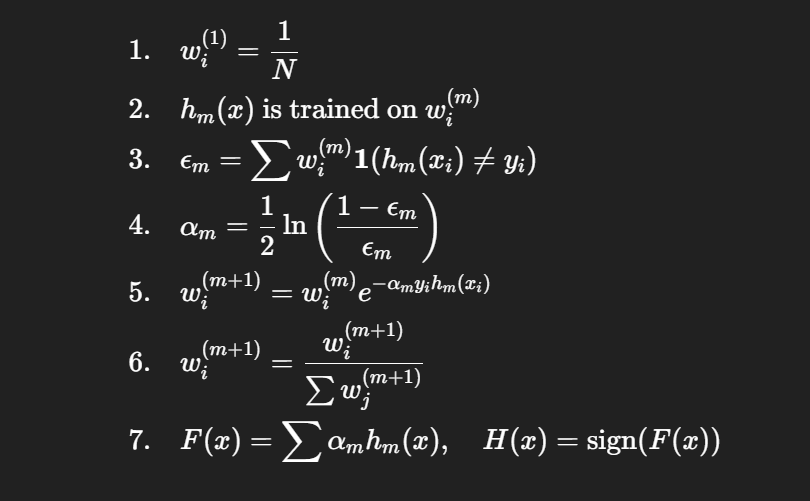

1.
Başlanğıcda bütün nümunələrin çəkisi bərabərdir.

Niyə?
Model hələ bilmir hansı nümunə çətindir, hamısı eyni dərəcədə vacibdir.

2.
m-ci zəif learner (decision stump) cari çəkilərlə öyrədilir.

Niyə?
Çəkilər dəyişdikcə model “çətin” nümunələrə daha çox fokuslanır.

3.
Weak learner-in weighted error-ıdır (səhv etdiyi nümunələrin toplam çəkisi).

Niyə?
Çəkilər fərqli olduğuna görə bəzi nümunələr səhv ediləndə daha çox “cəzalandırılır”.


4.
Weak learner-in final modeldə nə qədər güclü iştirak edəcəyini müəyyən edən çəki.

Niyə?
Az səhv → böyük α → model güclüdir
Çox səhv → kiçik α → model zəifdir

Bu, yaxşı modelləri daha çox “səs”lə finala salır.

5.
Növbəti iterasiya üçün nümunələrin çəkilərinin yenilənməsidir.

Niyə?
Düzgün proqnoz=1 → exponent mənfi → weight azalır

SEhv proqnoz=−1 → exponent müsbət → weight artır

Yəni model başa düşür:
“Hard cases” növbəti model üçün daha vacibdir.

6.
Normalize edilmiş çəkilər → toplamı 1 olur.

Niyə?
Boosting hər iterasiyada çəkiləri ehtimal paylanmasına çevirməlidir
(onsuz training prosesi qeyri-sabit olar).

7.
F(x): weak learner-lərin weighted sum-u (real-valued score)
H(x): final prediction (sign → +1 və ya –1)

Niyə?
Çünki bir weak learner gücsüzdür, amma çoxlu weak learner-in ağıllı birləşməsi güclü model yaradır.



#GRADINET BOOSTING

Gradient boosting builds models sequentially and corrects errors along the way. It uses a gradient descent algorithm to minimize the loss when adding new models. This method is flexible and can be used for both regression and classification problems.

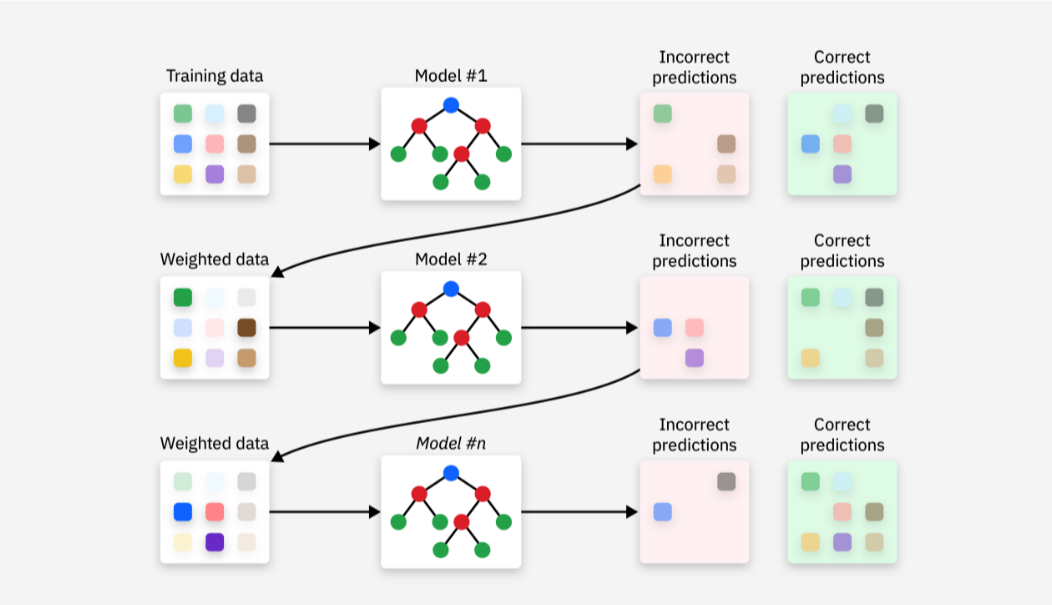

One of the key benefits of gradient boosting is its ability to iteratively minimize the loss function, resulting in improved predictive accuracy. However, one must be conscious of overfitting, which occurs when a model becomes too specialized to the training data and fails to generalize well to new instances. To mitigate this risk, practitioners must carefully tune hyperparameters, monitor model performance during training and employ techniques like regularization, pruning or early stopping

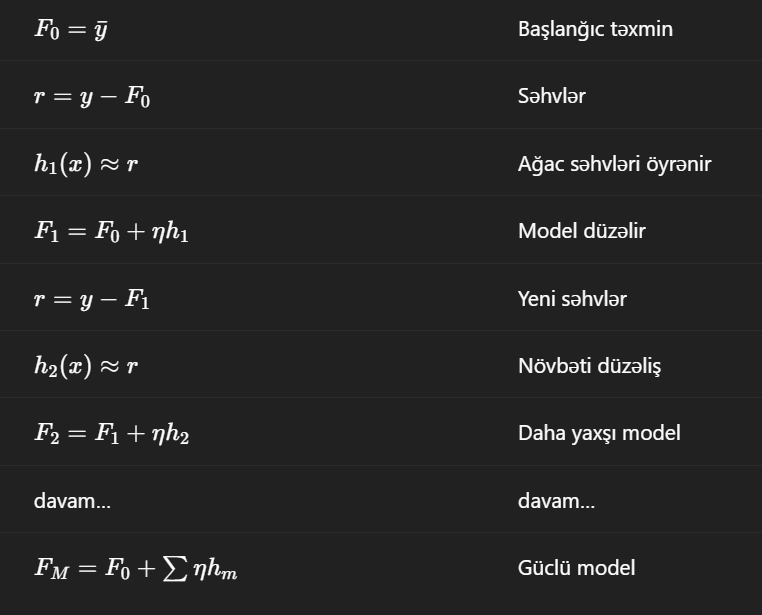

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=150,   # number of boosting stages (trees)
    learning_rate=0.1,  # shrinkage parameter
    max_depth=3,        # depth of individual trees (controls model complexity)
    subsample=1.0,      # if <0 → stochastic gradient boosting
    random_state=42
)


gb_clf = Pipeline(steps=[
    ("preprocess", transformer),
    ("gb", gb)
])

gb_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness...
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40'],
      dtype='object'))])),
                ('gb',
                 GradientBoostingClassifier(n_estimators=150,
                                            random_state=42))])

In [ ]:
gb_clf.score(X_train, y_train), gb_clf.score(X_test, y_test)

In [ ]:
y_pred = gb_clf.predict(X_test)

print("Gradient Boosting Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report (GB):\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix (GB):\n", confusion_matrix(y_test, y_pred))

Gradient Boosting Test Accuracy: 0.8095238095238095

Classification Report (GB):
               precision    recall  f1-score   support

           1       0.79      0.73      0.76        15
           2       0.81      0.85      0.83        20
           3       1.00      1.00      1.00         3
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         1
           7       0.67      1.00      0.80         2

    accuracy                           0.81        42
   macro avg       0.71      0.76      0.73        42
weighted avg       0.79      0.81      0.80        42


Confusion Matrix (GB):
 [[11  3  0  0  0  1]
 [ 3 17  0  0  0  0]
 [ 0  0  3  0  0  0]
 [ 0  1  0  0  0  0]
 [ 0  0  0  0  1  0]
 [ 0  0  0  0  0  2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


AdaBoost çəkiləri düzəldir,
Gradient Boosting residual-ları.

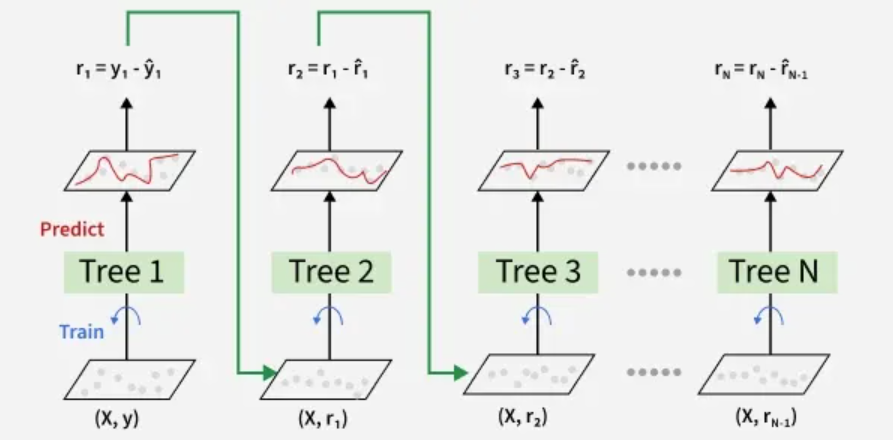

# Extreme Gradient Boosting  (XG)

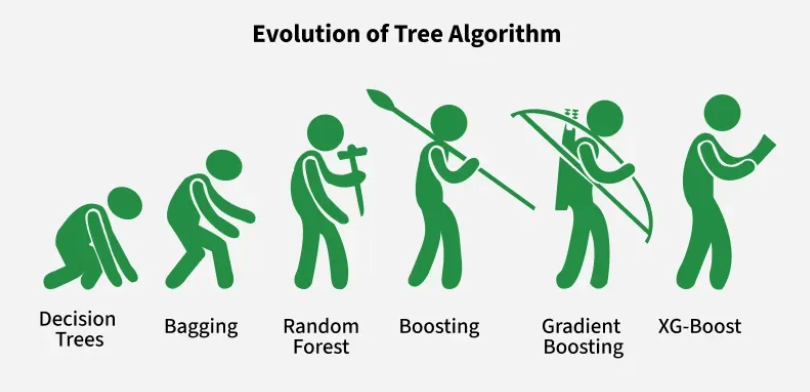

It builds decision trees sequentially with each tree attempting to correct the mistakes made by the previous one. The process can be broken down as follows:

1.Start with a base learner: The first model decision tree is trained on the data. In regression tasks this base model simply predicts the average of the target variable.

2.Calculate the errors: After training the first tree the errors between the predicted and actual values are calculated.

3.Train the next tree: The next tree is trained on the errors of the previous tree. This step attempts to correct the errors made by the first tree.

4.Repeat the process: This process continues with each new tree trying to correct the errors of the previous trees until a stopping criterion is met.

5.Combine the predictions: The final prediction is the sum of the predictions from all the trees.

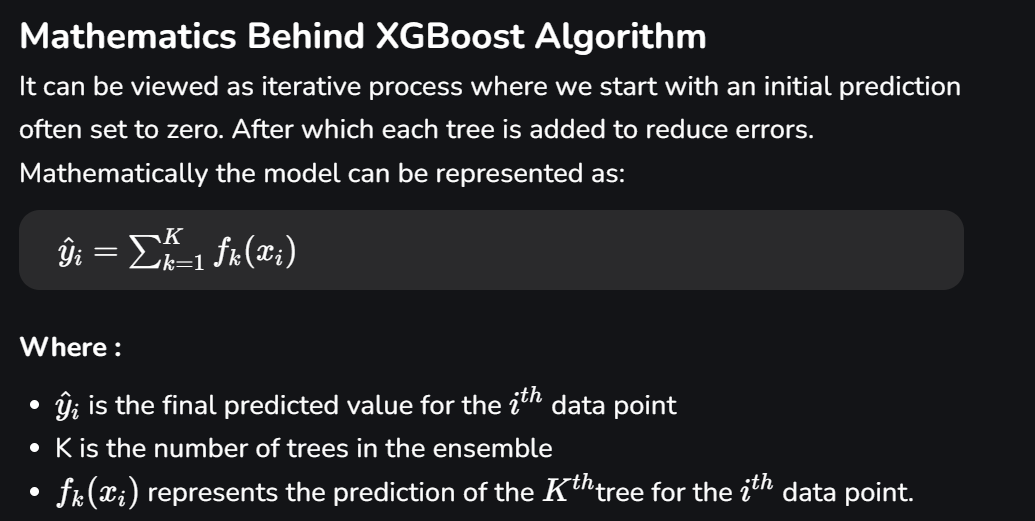

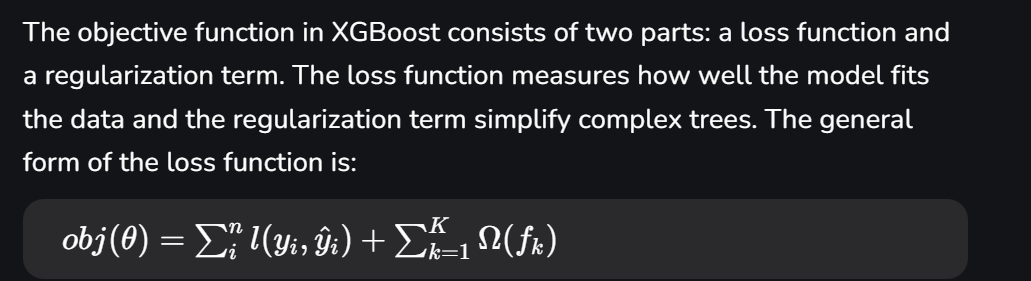

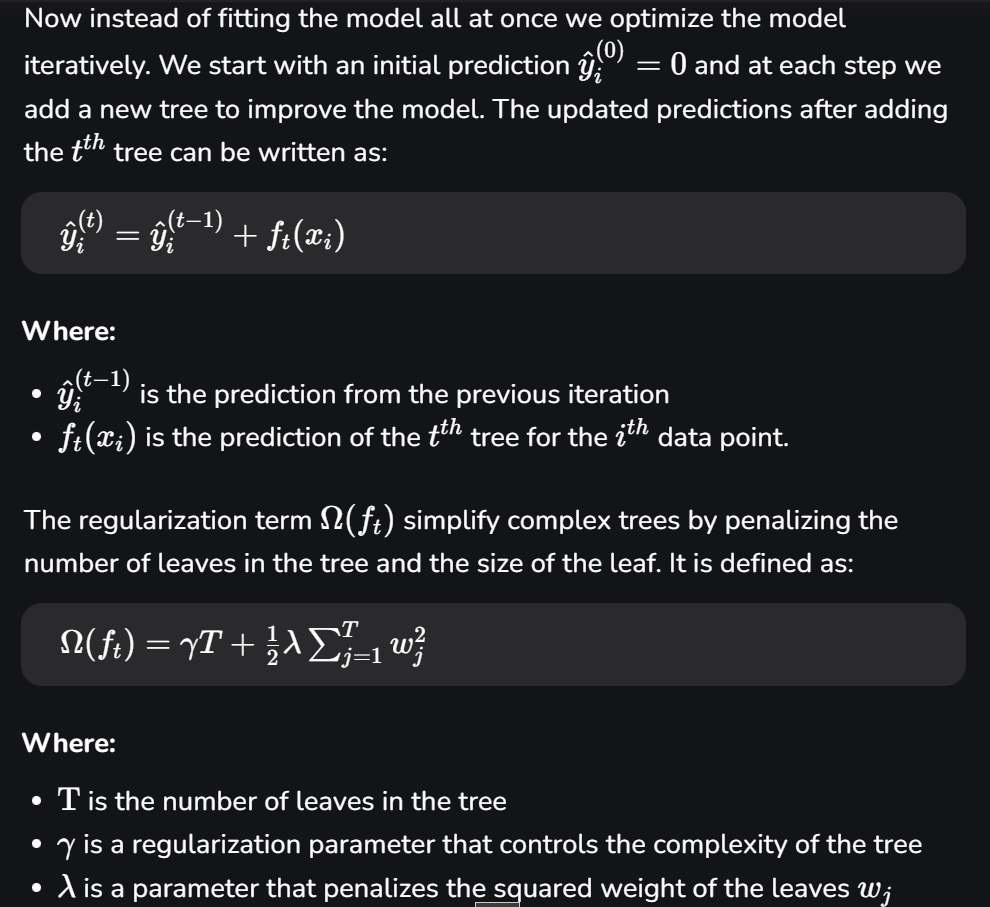

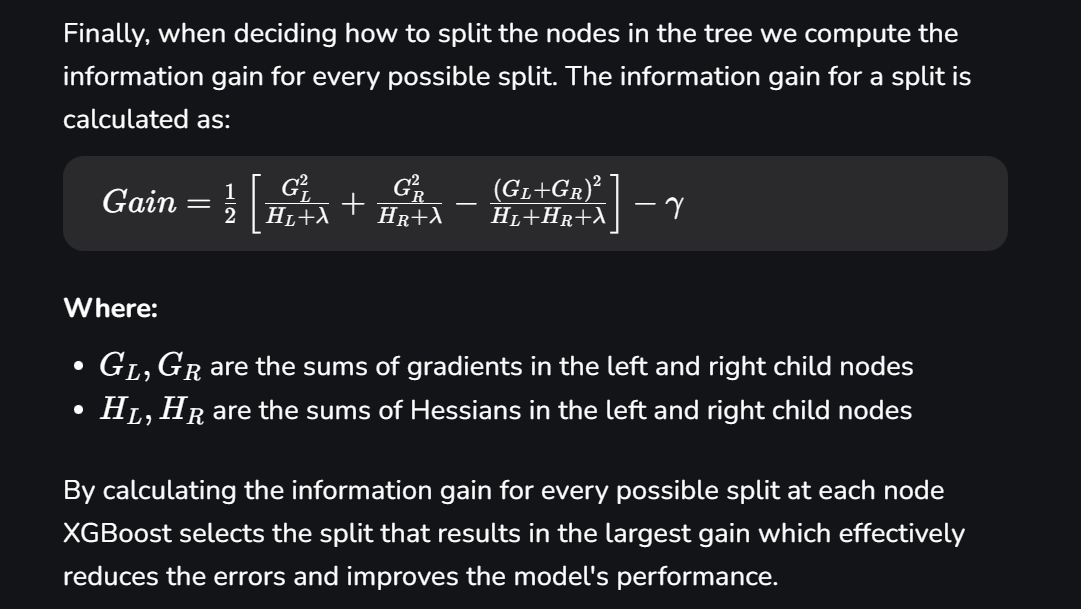

What Makes XGBoost "eXtreme"?
1. Preventing Overfitting
Learning rate (eta): Controls each tree’s contribution; a lower value makes the model more conservative.
Regularization: Adds penalties to complexity to prevent overly complex trees.
Pruning: Trees grow depth-wise, and splits that do not improve the objective function are removed, keeping trees simpler and faster.
Combination effect: Using learning rate, regularization, and pruning together enhances robustness and reduces overfitting.
2. Tree Structure
XGBoost builds trees level-wise (breadth-first) rather than the conventional depth-first approach, adding nodes at each depth before moving to the next level.
3. Handling Missing Data
XGBoost manages missing values robustly during training and prediction using a sparsity-aware approach.

Sparsity-Aware Split Finding: Treats missing values as a separate category when evaluating splits.
Default direction: During tree building, missing values follow a default branch.
Prediction: Instances with missing features follow the learned default branch.
Benefit: Ensures robust predictions even with incomplete input data.

4. Cache-Aware Access
XGBoost optimizes memory usage to speed up computations by taking advantage of CPU cache.

XGBoost-un əsas ideyası:
 Loss funksiyasını Taylor genişlənməsi ilə yaxınlaşdır və ən yaxşı ağacı bu aproxima­siya ilə qur.
XGBoost loss-u birbaşa minimallaşdırmır. O onu local approximation ilə sadələşdirir:Loss-u Taylor seriyası ilə açır

Gradient → “səhvə doğru hansı istiqamətdə düzəliş edim?”
Hessian → “bu istiqamətdə nə qədər agresiv düzəliş edim?”

Gradient Boosting + 2nd order optimization + regularization + smart splitting = XGBoost.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report


"""
XGBoost Multi-Class Label Error — Explanation

Error:
    ValueError: Invalid classes inferred from unique values of y.
    Expected: [0 1 2 3 4 5 6], got [1 2 3 4 5 6 7]

Why this happens:
    XGBoost doesn’t care whether labels are integers —
    it cares that labels are contiguous integers starting at 0.

    For a multi-class problem with K classes, valid labels must be:
        0, 1, 2, ..., K−1

    But this dataset has labels:
        1, 2, 3, 4, 5, 6, 7
    So we must remap them to:
        0, 1, 2, 3, 4, 5, 6

XGBoost rule:
    All class labels must be in the range [0, num_class).
    Example: For 3 classes → valid labels = 0, 1, 2.

Reference:
    https://github.com/dmlc/xgboost/issues/11228
"""

y_train_adj = y_train - 1
y_test_adj = y_test - 1

xg_boos_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    reg_alpha=0,
    tree_method="hist",
    random_state=42
)

xg_boos_model.fit(X_train, y_train_adj)




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xg_boos_model.score(X_train, y_train_adj), xg_boos_model.score(X_test, y_test_adj)

(0.8766115289946125, 0.8571428571428571)

In [ ]:
y_pred_adj = xg_boos_model.predict(X_test)


y_pred = y_pred_adj + 1


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

           1       0.76      0.87      0.81        15
           2       0.94      0.80      0.86        20
           3       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       0.67      1.00      0.80         2

    accuracy                           0.86        42
   macro avg       0.90      0.94      0.91        42
weighted avg       0.87      0.86      0.86        42



#Light Boosting

LightGBM is an open-source high-performance framework developed by Microsoft. It is an ensemble learning framework that uses gradient boosting method which constructs a strong learner by sequentially adding weak learners in a gradient descent manner.

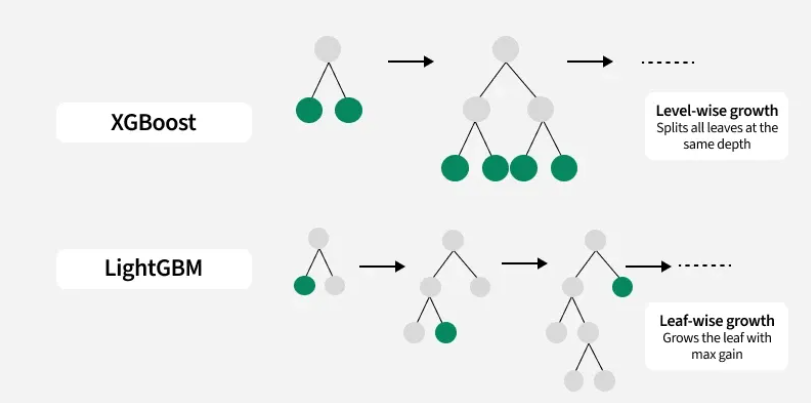

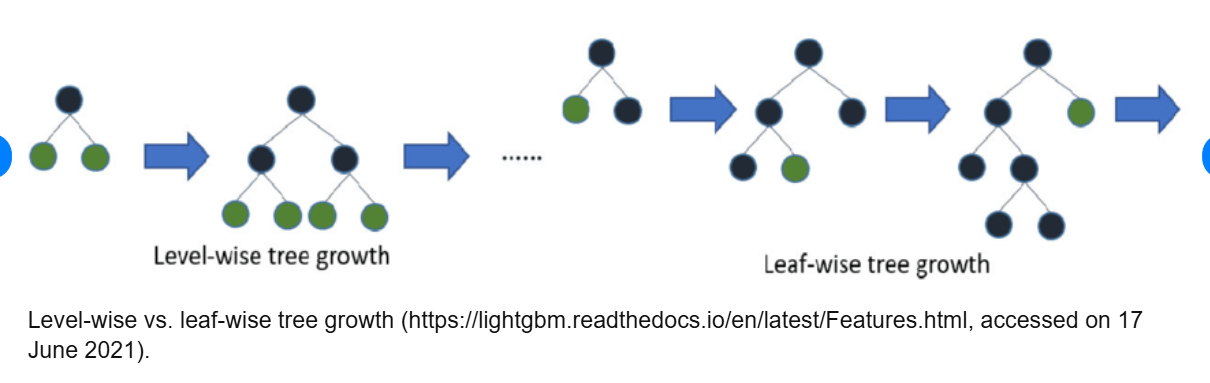

The implementation introduces two key ideas: GOSS and EFB.

Gradient-based One-Side Sampling, or GOSS for short, is a modification to the gradient boosting method that focuses attention on those training examples that result in a larger gradient, in turn speeding up learning and reducing the computational complexity of the method


Exclusive Feature Bundling, or EFB for short, is an approach for bundling sparse (mostly zero) mutually exclusive features, such as categorical variable inputs that have been one-hot encoded. As such, it is a type of automatic feature selection.

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Encode labels → SAME AS XGBOOST
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

model = LGBMClassifier(
    objective='multiclass',
    num_class=len(le.classes_),
    num_leaves=31,
    max_depth=-1,
    learning_rate=0.1,
    n_estimators=300,
    feature_fraction=0.8, # sutunlardan
    bagging_fraction=0.8,  # setirlerden
    bagging_freq=5,
    random_state=42
)

model.fit(X_train, y_train_enc)
y_pred_enc = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064026 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2265
[LightGBM] [Info] Number of data points in the train set: 580970, number of used features: 53
[LightGBM] [

In [ ]:
model.score(X_train, y_train_enc), model.score(X_test, y_test_enc)

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


(0.9140093292252612, 0.8809523809523809)

#Cat Boosting

CatBoost is an advanced gradient-boosting library specifically designed to address the challenges of handling categorical data in machine learning. CatBoost is an open-source technology that has become quite popular quickly because it can produce high-performance models without requiring a lot of data preprocessing. In contrast to other gradient boosting techniques, CatBoost is a superior option for tasks involving complicated, real-world datasets since it is good at handling categorical information natively.

CatBoost was created by Yandex, one of Russia's leading technology companies, known for its expertise in search engines, machine learning, and artificial intelligence.

Categorical features, such as customer IDs or product names, often pose challenges for machine learning models because they cannot be directly processed like numerical data. While most gradient-boosting algorithms require these features to be converted into numerical representations through methods like one-hot encoding, CatBoost natively handles categorical data. It automatically determines the best way to represent these features, significantly reducing the need for manual preprocessing. It works especially well when dealing with high-cardinality features, which is when a column has a huge number of distinct values.

Key features of CatBoost
1. Symmetric trees: CatBoost builds symmetric (balanced) trees, unlike XGBoost and LightGBM. In every step, leaves from the previous tree are split using the same condition.



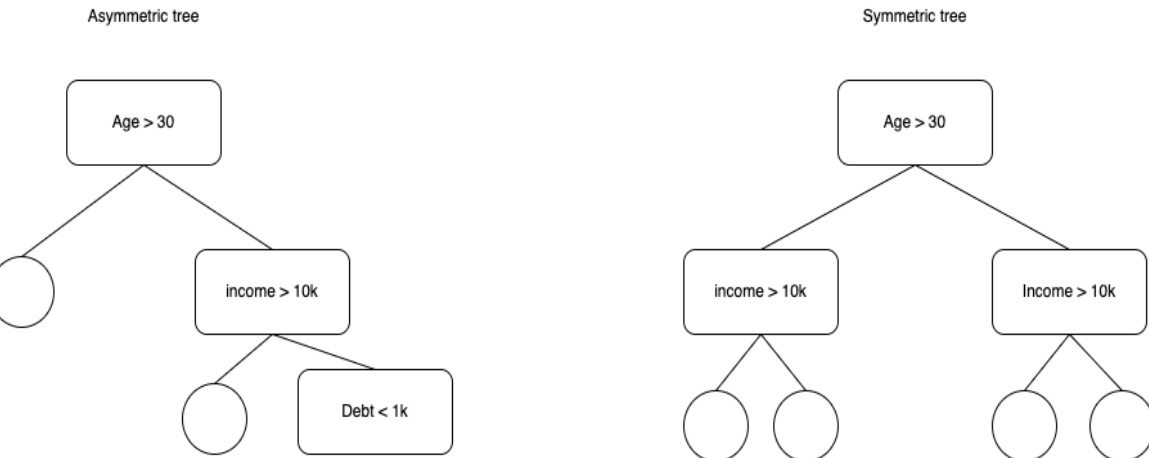

2. Native feature support: CatBoost supports all kinds of features, be it numeric, categorical, or text and saves time and effort that would have gone into preprocessing.

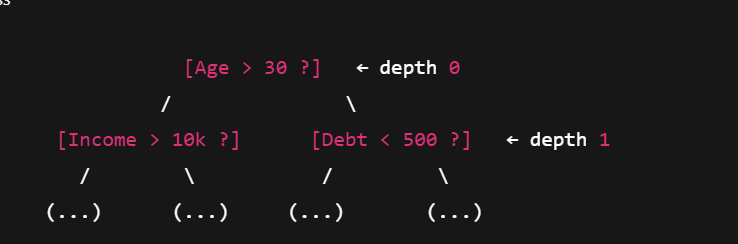

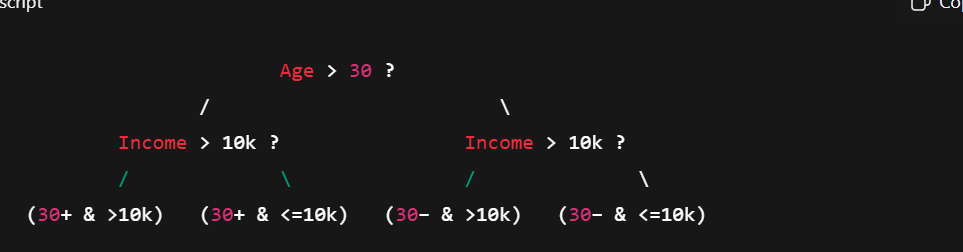

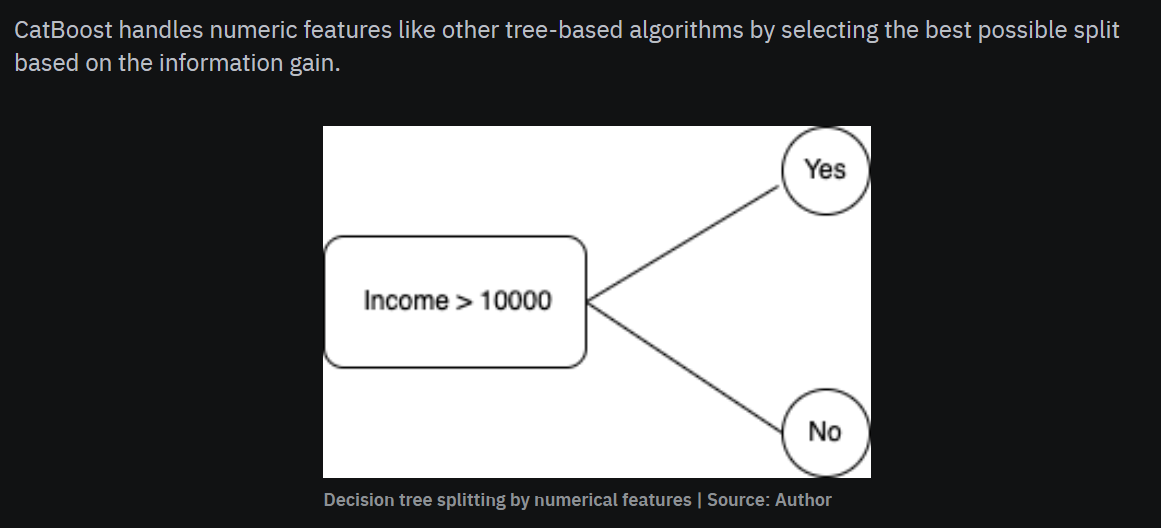

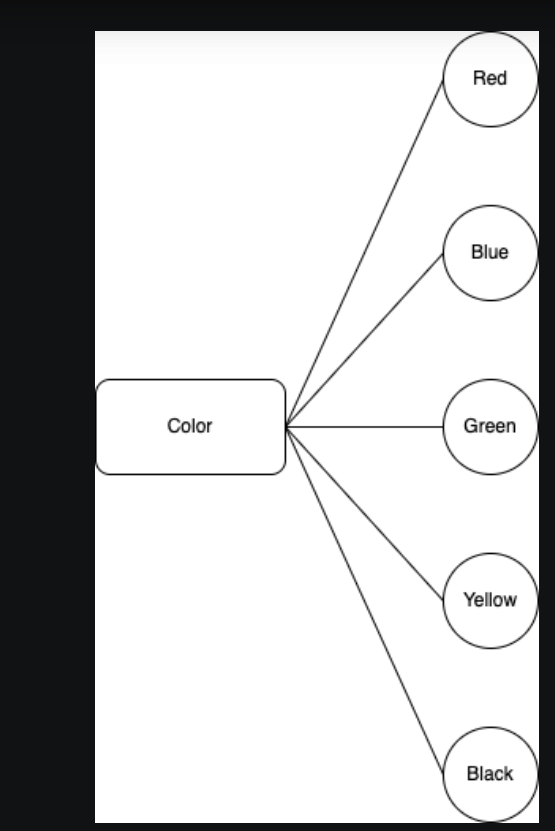

In [ ]:
!pip install catboost -q

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, classification_report

# Əgər y already 1–7-dirsə, CatBoost bunu qəbul edir.
# Amma istəsən LabelEncoder ilə 0–6 edə bilərsən, məcburi deyil.

# CatBoost data strukturu: Pool
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test, y_test)

cat_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="Accuracy",
    depth=6,            # tree depth
    learning_rate=0.1,
    iterations=300,     # boosting rounds
    random_seed=42,
    verbose=50          # hər 50 iterasiyada log
)

cat_model.fit(train_pool, eval_set=test_pool)

y_pred = cat_model.predict(X_test)
y_pred = y_pred.flatten()  # shape (n_samples, 1) → (n_samples,)

print("CatBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.2 MB/s eta 0:00:00
0:	learn: 0.6826050	test: 0.7142857	best: 0.7142857 (0)	total: 456ms	remaining: 2m 16s
50:	learn: 0.7415719	test: 0.7857143	best: 0.7857143 (43)	total: 21.4s	remaining: 1m 44s
100:	learn: 0.7716681	test: 0.7857143	best: 0.7857143 (43)	total: 43.3s	remaining: 1m 25s
150:	learn: 0.7895416	test: 0.7857143	best: 0.8095238 (118)	total: 1m 4s	remaining: 1m 3s
200:	learn: 0.8034942	test: 0.7857143	best: 0.8095238 (118)	total: 1m 28s	remaining: 43.5s
250:	learn: 0.8166859	test: 0.7857143	best: 0.8095238 (118)	total: 1m 56s	remaining: 22.8s
299:	learn: 0.8256072	test: 0.8333333	best: 0.8333333 (267)	total: 2m 21s	remaining: 0us

bestTest = 0.8333333333
bestIteration = 267

Shrink model to first 268 iterations.
CatBoost Accuracy: 0.8333333333333334

Classification Report:
               precision    recall  f1-score   support

           1       0.75      0.80      0.77        15
           2       0.89      0.80      

Ordered Boosting, a unique training scheme in the CatBoost algorithm designed to prevent target leakage and overfitting. Unlike classic gradient boosting which uses the whole dataset to calculate residuals, Ordered Boosting uses a permutation-driven approach to train each model on an ordered subset of data, only using historical information.

#Voting

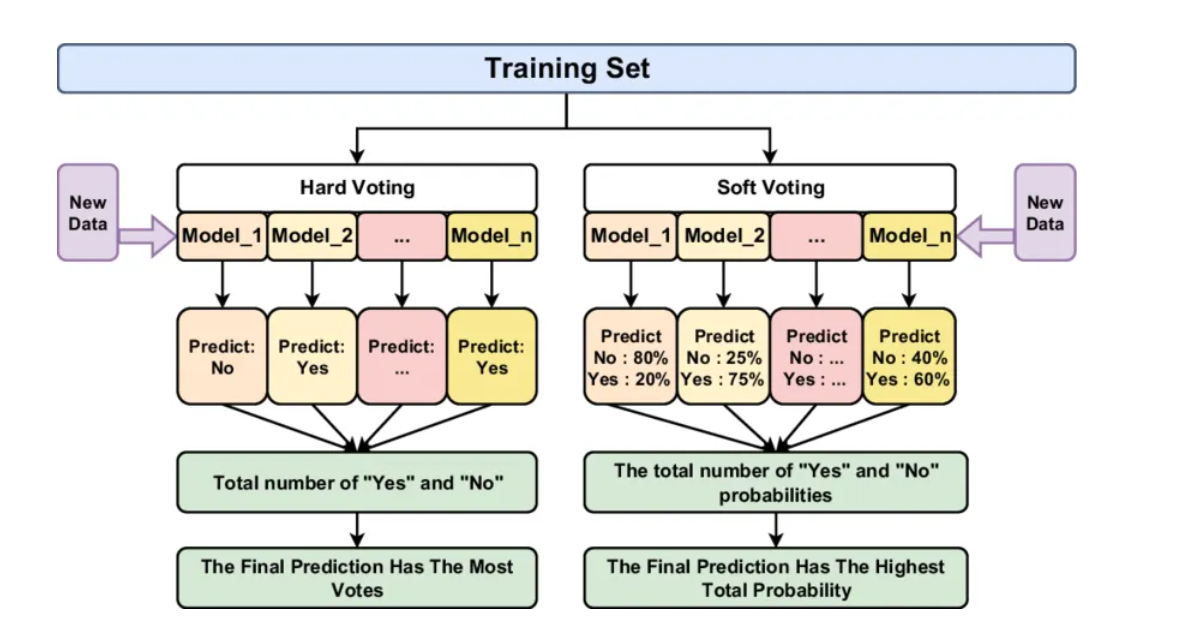

Machine learning models are powerful tools for solving complex problems, but no single model is perfect for every scenario. This is where ensemble methods come into play. Among these, Voting Classifiers have gained significant attention for their ability to combine the strengths of multiple models to improve overall performance.

A Voting Classifier is an ensemble learning technique that combines multiple classifiers and predicts the class based on a voting mechanism. This approach enhances model accuracy, reduces overfitting, and makes predictions more robust.

There are two types of voting classifiers:

Hard Voting: The final prediction is based on the majority vote of individual classifiers. For instance, if three classifiers predict [Class A, Class B, Class A], the final prediction will be Class A.

Soft Voting: Instead of counting votes, it averages the predicted probabilities of each classifier and selects the class with the highest probability.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

log_clf = LogisticRegression(max_iter=500)
svm_clf = SVC(probability=True)  # soft voting üçün lazımdır!  SVC Platt Scaling
rf_clf = RandomForestClassifier(n_estimators=200)


In [ ]:
from sklearn.ensemble import VotingClassifier

hard_vote = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('svm', svm_clf),
        ('rf', rf_clf)
    ],
    voting='hard'
)

hard_vote.fit(X_train, y_train)
print("Hard Voting Accuracy:", hard_vote.score(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
soft_vote = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('svm', svm_clf),
        ('rf', rf_clf)
    ],
    voting='soft'
)

soft_vote.fit(X_train, y_train)
print("Soft Voting Accuracy:", soft_vote.score(X_test, y_test))


#Stacking Model

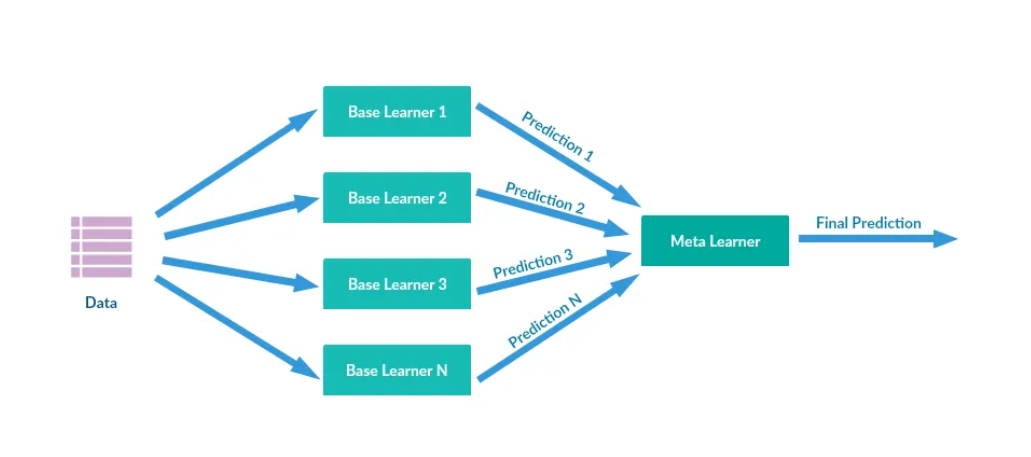

Stacking is one of the three widely used ensemble methods in Machine Learning and its applications. The overall idea of stacking is to train several models, usually with different algorithm types (aka base-learners), on the train data, and then rather than picking the best model, all the models are aggregated/fronted using another model (meta learner), to make the final prediction. The inputs for the meta-learner is the prediction outputs of the base-learners.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

#base learners
level1_models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=300)),
    ('gb', GradientBoostingClassifier())

]


In [ ]:
from sklearn.linear_model import LogisticRegression

#meta learner
meta_model = LogisticRegression()


In [ ]:
from sklearn.ensemble import StackingClassifier

stack_model = StackingClassifier(
    estimators=level1_models,
    final_estimator=meta_model,
    stack_method='predict_proba',  # daha yaxşı nəticə verir
    passthrough=False,  # X orijinal feature-ları meta-modelə vermir
    cv=5
)


In [ ]:
stack_model.fit(X_train, y_train)


In [ ]:
print("Stacking accuracy:", stack_model.score(X_test, y_test))


In [ ]:
# Variant: predict
# Base model çıxış olaraq class label verir.
# Məsələn Logistic → [0,1,1,0,0]

# Variant: predict_proba (ən yaxşısı!)
# Base model çıxış olaraq hər class üçün ehtimal verir.
# Məsələn:
# model.predict_proba(x) → [0.2, 0.8]
# Bu çıxış meta-model üçün çox zəngin məlumatdır:
# Model nə qədər əmindir?
# Boundary-dən nə qədər uzaqdadır?
# Class-lar necə bölgülənir?
# Nəticə: daha güclü stacking.

# Variant: decision_function
# Əgər model ehtimal dəstəkləmirsə (SVM kimi), decision_function istifadə olunur.
